In [1]:
!pip install kaggle

In [2]:
from google.colab import files
uploaded = files.upload()

Saving kaggle.json to kaggle.json


In [3]:
import os
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

In [5]:
!kaggle datasets download -d petalme/student-anxiety-dataset
!kaggle datasets download -d thedevastator/phq-9-depression-assessment

Dataset URL: https://www.kaggle.com/datasets/petalme/student-anxiety-dataset
License(s): apache-2.0
  0% 0.00/647k [00:00<?, ?B/s]
100% 647k/647k [00:00<00:00, 1.29GB/s]
Dataset URL: https://www.kaggle.com/datasets/thedevastator/phq-9-depression-assessment
License(s): CC0-1.0
  0% 0.00/385k [00:00<?, ?B/s]
100% 385k/385k [00:00<00:00, 1.00GB/s]


In [6]:
!unzip student-anxiety-dataset.zip
!unzip phq-9-depression-assessment.zip

Archive:  student-anxiety-dataset.zip
  inflating: anxiety.csv             
Archive:  phq-9-depression-assessment.zip
  inflating: Dataset_14-day_AA_depression_symptoms_mood_and_PHQ-9.csv  


In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import warnings
warnings.filterwarnings('ignore')

# Load datasets with different encodings
try:
    anxiety_df = pd.read_csv('anxiety.csv', encoding='utf-8')
except UnicodeDecodeError:
    anxiety_df = pd.read_csv('anxiety.csv', encoding='latin-1')

try:
    phq9_df = pd.read_csv('Dataset_14-day_AA_depression_symptoms_mood_and_PHQ-9.csv', encoding='utf-8')
except UnicodeDecodeError:
    phq9_df = pd.read_csv('Dataset_14-day_AA_depression_symptoms_mood_and_PHQ-9.csv', encoding='latin-1')

print("ANXIETY DATASET:")
print(f"Shape: {anxiety_df.shape}")
print("\nColumns:")
print(anxiety_df.columns.tolist())
print("\nFirst 5 rows:")
print(anxiety_df.head())

print("\n" + "="*50)

print("\nPHQ-9 DATASET:")
print(f"Shape: {phq9_df.shape}")
print("\nColumns:")
print(phq9_df.columns.tolist())
print("\nFirst 5 rows:")
print(phq9_df.head())

ANXIETY DATASET:
Shape: (13464, 55)

Columns:
['S. No.', 'Timestamp', 'GAD1', 'GAD2', 'GAD3', 'GAD4', 'GAD5', 'GAD6', 'GAD7', 'GADE', 'SWL1', 'SWL2', 'SWL3', 'SWL4', 'SWL5', 'Game', 'Platform', 'Hours', 'earnings', 'whyplay', 'League', 'highestleague', 'streams', 'SPIN1', 'SPIN2', 'SPIN3', 'SPIN4', 'SPIN5', 'SPIN6', 'SPIN7', 'SPIN8', 'SPIN9', 'SPIN10', 'SPIN11', 'SPIN12', 'SPIN13', 'SPIN14', 'SPIN15', 'SPIN16', 'SPIN17', 'Narcissism', 'Gender', 'Age', 'Work', 'Degree', 'Birthplace', 'Residence', 'Reference', 'Playstyle', 'accept', 'GAD_T', 'SWL_T', 'SPIN_T', 'Residence_ISO3', 'Birthplace_ISO3']

First 5 rows:
   S. No.    Timestamp  GAD1  GAD2  GAD3  GAD4  GAD5  GAD6  GAD7  \
0       1  42052.00437     0     0     0     0     1     0     0   
1       2  42052.00680     1     2     2     2     0     1     0   
2       3  42052.03860     0     2     2     0     0     3     1   
3       4  42052.06804     0     0     0     0     0     0     0   
4       5  42052.08948     2     1     2   

In [9]:
# Check target variables and missing values
print("ANXIETY DATASET ANALYSIS:")
print(f"GAD_T (GAD-7 Total Score) - Min: {anxiety_df['GAD_T'].min()}, Max: {anxiety_df['GAD_T'].max()}")
print(f"GAD_T distribution:\n{anxiety_df['GAD_T'].value_counts().sort_index()}")
print(f"Missing values in GAD columns:")
gad_cols = ['GAD1', 'GAD2', 'GAD3', 'GAD4', 'GAD5', 'GAD6', 'GAD7']
for col in gad_cols:
    print(f"{col}: {anxiety_df[col].isnull().sum()}")

print("\n" + "="*50)

print("\nPHQ-9 DATASET ANALYSIS:")
phq_cols = ['phq1', 'phq2', 'phq3', 'phq4', 'phq5', 'phq6', 'phq7', 'phq8', 'phq9']
print("PHQ-9 columns value ranges:")
for col in phq_cols:
    print(f"{col} - Min: {phq9_df[col].min()}, Max: {phq9_df[col].max()}, Missing: {phq9_df[col].isnull().sum()}")

# Calculate PHQ-9 total score
phq9_df['PHQ_TOTAL'] = phq9_df[phq_cols].sum(axis=1)
print(f"\nPHQ_TOTAL - Min: {phq9_df['PHQ_TOTAL'].min()}, Max: {phq9_df['PHQ_TOTAL'].max()}")
print(f"PHQ_TOTAL distribution:\n{phq9_df['PHQ_TOTAL'].value_counts().sort_index()}")

ANXIETY DATASET ANALYSIS:
GAD_T (GAD-7 Total Score) - Min: 0, Max: 21
GAD_T distribution:
GAD_T
0     1669
1     1485
2     1618
3     1455
4     1219
5     1024
6      849
7      720
8      598
9      475
10     407
11     367
12     308
13     292
14     239
15     160
16     144
17     113
18      86
19      70
20      35
21     131
Name: count, dtype: int64
Missing values in GAD columns:
GAD1: 0
GAD2: 0
GAD3: 0
GAD4: 0
GAD5: 0
GAD6: 0
GAD7: 0


PHQ-9 DATASET ANALYSIS:
PHQ-9 columns value ranges:
phq1 - Min: 0.0, Max: 3.0, Missing: 286
phq2 - Min: 0.0, Max: 3.0, Missing: 537
phq3 - Min: 0.0, Max: 3.0, Missing: 537
phq4 - Min: 0.0, Max: 3.0, Missing: 537
phq5 - Min: 0.0, Max: 3.0, Missing: 537
phq6 - Min: 0.0, Max: 3.0, Missing: 537
phq7 - Min: 0.0, Max: 3.0, Missing: 537
phq8 - Min: 0.0, Max: 3.0, Missing: 537
phq9 - Min: 0.0, Max: 3.0, Missing: 537

PHQ_TOTAL - Min: 0.0, Max: 27.0
PHQ_TOTAL distribution:
PHQ_TOTAL
0.0      483
2.0       54
3.0      157
4.0      728
5.0      607
6.0

In [10]:
# Clean PHQ-9 dataset - remove missing values
phq9_clean = phq9_df.dropna(subset=phq_cols)
print(f"PHQ-9 dataset shape after removing missing values: {phq9_clean.shape}")

# Recalculate PHQ total score for clean data
phq9_clean['PHQ_TOTAL'] = phq9_clean[phq_cols].sum(axis=1)

# Create severity categories for PHQ-9 (0-4: minimal, 5-9: mild, 10-14: moderate, 15-19: moderate-severe, 20-27: severe)
def categorize_phq9(score):
    if score <= 4:
        return 0  # minimal
    elif score <= 9:
        return 1  # mild
    elif score <= 14:
        return 2  # moderate
    elif score <= 19:
        return 3  # moderate-severe
    else:
        return 4  # severe

phq9_clean['PHQ_CATEGORY'] = phq9_clean['PHQ_TOTAL'].apply(categorize_phq9)

# Create severity categories for GAD-7 (0-4: minimal, 5-9: mild, 10-14: moderate, 15-21: severe)
def categorize_gad7(score):
    if score <= 4:
        return 0  # minimal
    elif score <= 9:
        return 1  # mild
    elif score <= 14:
        return 2  # moderate
    else:
        return 3  # severe

anxiety_df['GAD_CATEGORY'] = anxiety_df['GAD_T'].apply(categorize_gad7)

print(f"PHQ-9 categories distribution:\n{phq9_clean['PHQ_CATEGORY'].value_counts().sort_index()}")
print(f"GAD-7 categories distribution:\n{anxiety_df['GAD_CATEGORY'].value_counts().sort_index()}")

PHQ-9 dataset shape after removing missing values: (15613, 37)
PHQ-9 categories distribution:
PHQ_CATEGORY
0     885
1    2204
2    3405
3    4062
4    5057
Name: count, dtype: int64
GAD-7 categories distribution:
GAD_CATEGORY
0    7446
1    3666
2    1613
3     739
Name: count, dtype: int64


In [11]:
# Prepare GAD-7 training data
gad_features = ['GAD1', 'GAD2', 'GAD3', 'GAD4', 'GAD5', 'GAD6', 'GAD7']
X_gad = anxiety_df[gad_features]
y_gad = anxiety_df['GAD_CATEGORY']

print(f"GAD-7 Training Data Shape: {X_gad.shape}")
print(f"GAD-7 Target Shape: {y_gad.shape}")
print(f"GAD-7 Feature columns: {gad_features}")

# Check class distribution
print(f"GAD-7 class distribution:")
for i in range(4):
    count = (y_gad == i).sum()
    pct = count / len(y_gad) * 100
    print(f"Class {i}: {count} samples ({pct:.1f}%)")

# Prepare PHQ-9 training data
phq_features = ['phq1', 'phq2', 'phq3', 'phq4', 'phq5', 'phq6', 'phq7', 'phq8', 'phq9']
X_phq = phq9_clean[phq_features]
y_phq = phq9_clean['PHQ_CATEGORY']

print(f"\nPHQ-9 Training Data Shape: {X_phq.shape}")
print(f"PHQ-9 Target Shape: {y_phq.shape}")
print(f"PHQ-9 Feature columns: {phq_features}")

# Check class distribution
print(f"PHQ-9 class distribution:")
for i in range(5):
    count = (y_phq == i).sum()
    pct = count / len(y_phq) * 100
    print(f"Class {i}: {count} samples ({pct:.1f}%)")

GAD-7 Training Data Shape: (13464, 7)
GAD-7 Target Shape: (13464,)
GAD-7 Feature columns: ['GAD1', 'GAD2', 'GAD3', 'GAD4', 'GAD5', 'GAD6', 'GAD7']
GAD-7 class distribution:
Class 0: 7446 samples (55.3%)
Class 1: 3666 samples (27.2%)
Class 2: 1613 samples (12.0%)
Class 3: 739 samples (5.5%)

PHQ-9 Training Data Shape: (15613, 9)
PHQ-9 Target Shape: (15613,)
PHQ-9 Feature columns: ['phq1', 'phq2', 'phq3', 'phq4', 'phq5', 'phq6', 'phq7', 'phq8', 'phq9']
PHQ-9 class distribution:
Class 0: 885 samples (5.7%)
Class 1: 2204 samples (14.1%)
Class 2: 3405 samples (21.8%)
Class 3: 4062 samples (26.0%)
Class 4: 5057 samples (32.4%)


In [12]:
from imblearn.over_sampling import SMOTE
from collections import Counter

# Apply SMOTE to GAD-7 data
smote_gad = SMOTE(random_state=42)
X_gad_balanced, y_gad_balanced = smote_gad.fit_resample(X_gad, y_gad)

print("GAD-7 Data Balancing:")
print(f"Original distribution: {Counter(y_gad)}")
print(f"Balanced distribution: {Counter(y_gad_balanced)}")
print(f"Original shape: {X_gad.shape}")
print(f"Balanced shape: {X_gad_balanced.shape}")

# Apply SMOTE to PHQ-9 data
smote_phq = SMOTE(random_state=42)
X_phq_balanced, y_phq_balanced = smote_phq.fit_resample(X_phq, y_phq)

print(f"\nPHQ-9 Data Balancing:")
print(f"Original distribution: {Counter(y_phq)}")
print(f"Balanced distribution: {Counter(y_phq_balanced)}")
print(f"Original shape: {X_phq.shape}")
print(f"Balanced shape: {X_phq_balanced.shape}")

GAD-7 Data Balancing:
Original distribution: Counter({0: 7446, 1: 3666, 2: 1613, 3: 739})
Balanced distribution: Counter({0: 7446, 1: 7446, 2: 7446, 3: 7446})
Original shape: (13464, 7)
Balanced shape: (29784, 7)

PHQ-9 Data Balancing:
Original distribution: Counter({4: 5057, 3: 4062, 2: 3405, 1: 2204, 0: 885})
Balanced distribution: Counter({4: 5057, 1: 5057, 3: 5057, 2: 5057, 0: 5057})
Original shape: (15613, 9)
Balanced shape: (25285, 9)


In [13]:
from sklearn.preprocessing import StandardScaler

# Split GAD-7 data
X_gad_train, X_gad_test, y_gad_train, y_gad_test = train_test_split(
    X_gad_balanced, y_gad_balanced, test_size=0.2, random_state=42, stratify=y_gad_balanced
)

# Split PHQ-9 data
X_phq_train, X_phq_test, y_phq_train, y_phq_test = train_test_split(
    X_phq_balanced, y_phq_balanced, test_size=0.2, random_state=42, stratify=y_phq_balanced
)

# Scale the features
scaler_gad = StandardScaler()
X_gad_train_scaled = scaler_gad.fit_transform(X_gad_train)
X_gad_test_scaled = scaler_gad.transform(X_gad_test)

scaler_phq = StandardScaler()
X_phq_train_scaled = scaler_phq.fit_transform(X_phq_train)
X_phq_test_scaled = scaler_phq.transform(X_phq_test)

print("GAD-7 Split:")
print(f"Train shape: {X_gad_train_scaled.shape}")
print(f"Test shape: {X_gad_test_scaled.shape}")
print(f"Train target distribution: {Counter(y_gad_train)}")

print(f"\nPHQ-9 Split:")
print(f"Train shape: {X_phq_train_scaled.shape}")
print(f"Test shape: {X_phq_test_scaled.shape}")
print(f"Train target distribution: {Counter(y_phq_train)}")

GAD-7 Split:
Train shape: (23827, 7)
Test shape: (5957, 7)
Train target distribution: Counter({0: 5957, 1: 5957, 3: 5957, 2: 5956})

PHQ-9 Split:
Train shape: (20228, 9)
Test shape: (5057, 9)
Train target distribution: Counter({2: 4046, 1: 4046, 4: 4046, 0: 4045, 3: 4045})


In [14]:
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report

# Train multiple models for GAD-7
models_gad = {
    'RandomForest': RandomForestClassifier(n_estimators=200, random_state=42, max_depth=10),
    'GradientBoosting': GradientBoostingClassifier(n_estimators=200, random_state=42, max_depth=6),
    'LogisticRegression': LogisticRegression(random_state=42, max_iter=1000),
    'SVM': SVC(random_state=42, kernel='rbf')
}

gad_results = {}

print("Training GAD-7 Models:")
for name, model in models_gad.items():
    print(f"Training {name}...")
    model.fit(X_gad_train_scaled, y_gad_train)
    y_pred = model.predict(X_gad_test_scaled)
    accuracy = accuracy_score(y_gad_test, y_pred)
    gad_results[name] = accuracy
    print(f"{name} Accuracy: {accuracy:.4f}")

print(f"\nBest GAD-7 Model: {max(gad_results, key=gad_results.get)} with accuracy: {max(gad_results.values()):.4f}")

Training GAD-7 Models:
Training RandomForest...
RandomForest Accuracy: 0.9760
Training GradientBoosting...
GradientBoosting Accuracy: 0.9847
Training LogisticRegression...
LogisticRegression Accuracy: 0.9770
Training SVM...
SVM Accuracy: 0.9847

Best GAD-7 Model: GradientBoosting with accuracy: 0.9847


In [15]:
# Train multiple models for PHQ-9
models_phq = {
    'RandomForest': RandomForestClassifier(n_estimators=200, random_state=42, max_depth=10),
    'GradientBoosting': GradientBoostingClassifier(n_estimators=200, random_state=42, max_depth=6),
    'LogisticRegression': LogisticRegression(random_state=42, max_iter=1000),
    'SVM': SVC(random_state=42, kernel='rbf')
}

phq_results = {}

print("Training PHQ-9 Models:")
for name, model in models_phq.items():
    print(f"Training {name}...")
    model.fit(X_phq_train_scaled, y_phq_train)
    y_pred = model.predict(X_phq_test_scaled)
    accuracy = accuracy_score(y_phq_test, y_pred)
    phq_results[name] = accuracy
    print(f"{name} Accuracy: {accuracy:.4f}")

print(f"\nBest PHQ-9 Model: {max(phq_results, key=phq_results.get)} with accuracy: {max(phq_results.values()):.4f}")

Training PHQ-9 Models:
Training RandomForest...
RandomForest Accuracy: 1.0000
Training GradientBoosting...
GradientBoosting Accuracy: 1.0000
Training LogisticRegression...
LogisticRegression Accuracy: 1.0000
Training SVM...
SVM Accuracy: 1.0000

Best PHQ-9 Model: RandomForest with accuracy: 1.0000


In [16]:
best_gad_model = models_gad['GradientBoosting']
best_phq_model = models_phq['RandomForest']

# GAD-7 detailed evaluation
print("GAD-7 DETAILED EVALUATION:")
y_gad_pred = best_gad_model.predict(X_gad_test_scaled)
gad_accuracy = accuracy_score(y_gad_test, y_gad_pred)
print(f"Exact Accuracy: {gad_accuracy}")
print(f"Correct Predictions: {(y_gad_test == y_gad_pred).sum()}")
print(f"Total Predictions: {len(y_gad_test)}")
print(f"Wrong Predictions: {(y_gad_test != y_gad_pred).sum()}")

print("\nGAD-7 Classification Report:")
print(classification_report(y_gad_test, y_gad_pred))

print("="*50)

# PHQ-9 detailed evaluation
print("PHQ-9 DETAILED EVALUATION:")
y_phq_pred = best_phq_model.predict(X_phq_test_scaled)
phq_accuracy = accuracy_score(y_phq_test, y_phq_pred)
print(f"Exact Accuracy: {phq_accuracy}")
print(f"Correct Predictions: {(y_phq_test == y_phq_pred).sum()}")
print(f"Total Predictions: {len(y_phq_test)}")
print(f"Wrong Predictions: {(y_phq_test != y_phq_pred).sum()}")

print("\nPHQ-9 Classification Report:")
print(classification_report(y_phq_test, y_phq_pred))

GAD-7 DETAILED EVALUATION:
Exact Accuracy: 0.9847238542890717
Correct Predictions: 5866
Total Predictions: 5957
Wrong Predictions: 91

GAD-7 Classification Report:
              precision    recall  f1-score   support

           0       1.00      0.99      0.99      1489
           1       0.98      0.97      0.98      1489
           2       0.97      0.98      0.97      1490
           3       0.99      0.99      0.99      1489

    accuracy                           0.98      5957
   macro avg       0.98      0.98      0.98      5957
weighted avg       0.98      0.98      0.98      5957

PHQ-9 DETAILED EVALUATION:
Exact Accuracy: 1.0
Correct Predictions: 5057
Total Predictions: 5057
Wrong Predictions: 0

PHQ-9 Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      1012
           1       1.00      1.00      1.00      1011
           2       1.00      1.00      1.00      1011
           3       1.00      1.00   

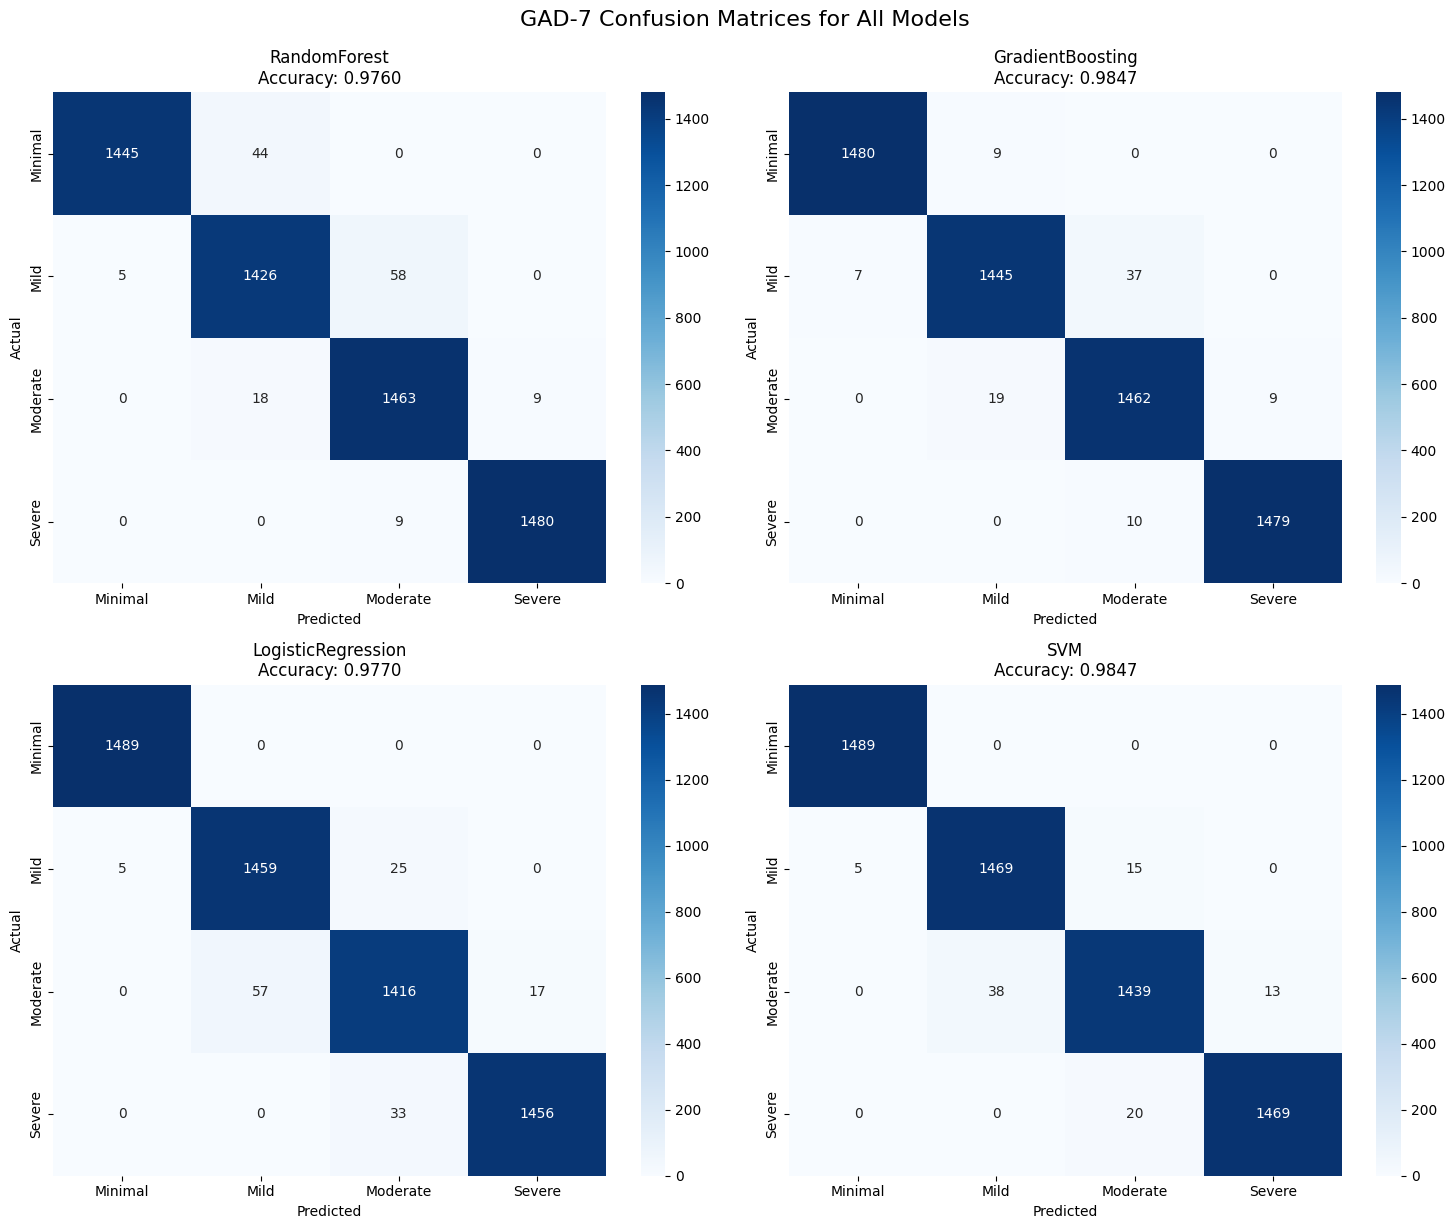

In [17]:
import matplotlib.pyplot as plt
import seaborn as sns

fig, axes = plt.subplots(2, 2, figsize=(15, 12))
axes = axes.ravel()

for idx, (name, model) in enumerate(models_gad.items()):
    y_pred = model.predict(X_gad_test_scaled)
    cm = confusion_matrix(y_gad_test, y_pred)
    accuracy = accuracy_score(y_gad_test, y_pred)

    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=['Minimal', 'Mild', 'Moderate', 'Severe'],
                yticklabels=['Minimal', 'Mild', 'Moderate', 'Severe'],
                ax=axes[idx])

    axes[idx].set_title(f'{name}\nAccuracy: {accuracy:.4f}')
    axes[idx].set_xlabel('Predicted')
    axes[idx].set_ylabel('Actual')

plt.tight_layout()
plt.suptitle('GAD-7 Confusion Matrices for All Models', y=1.02, fontsize=16)
plt.show()

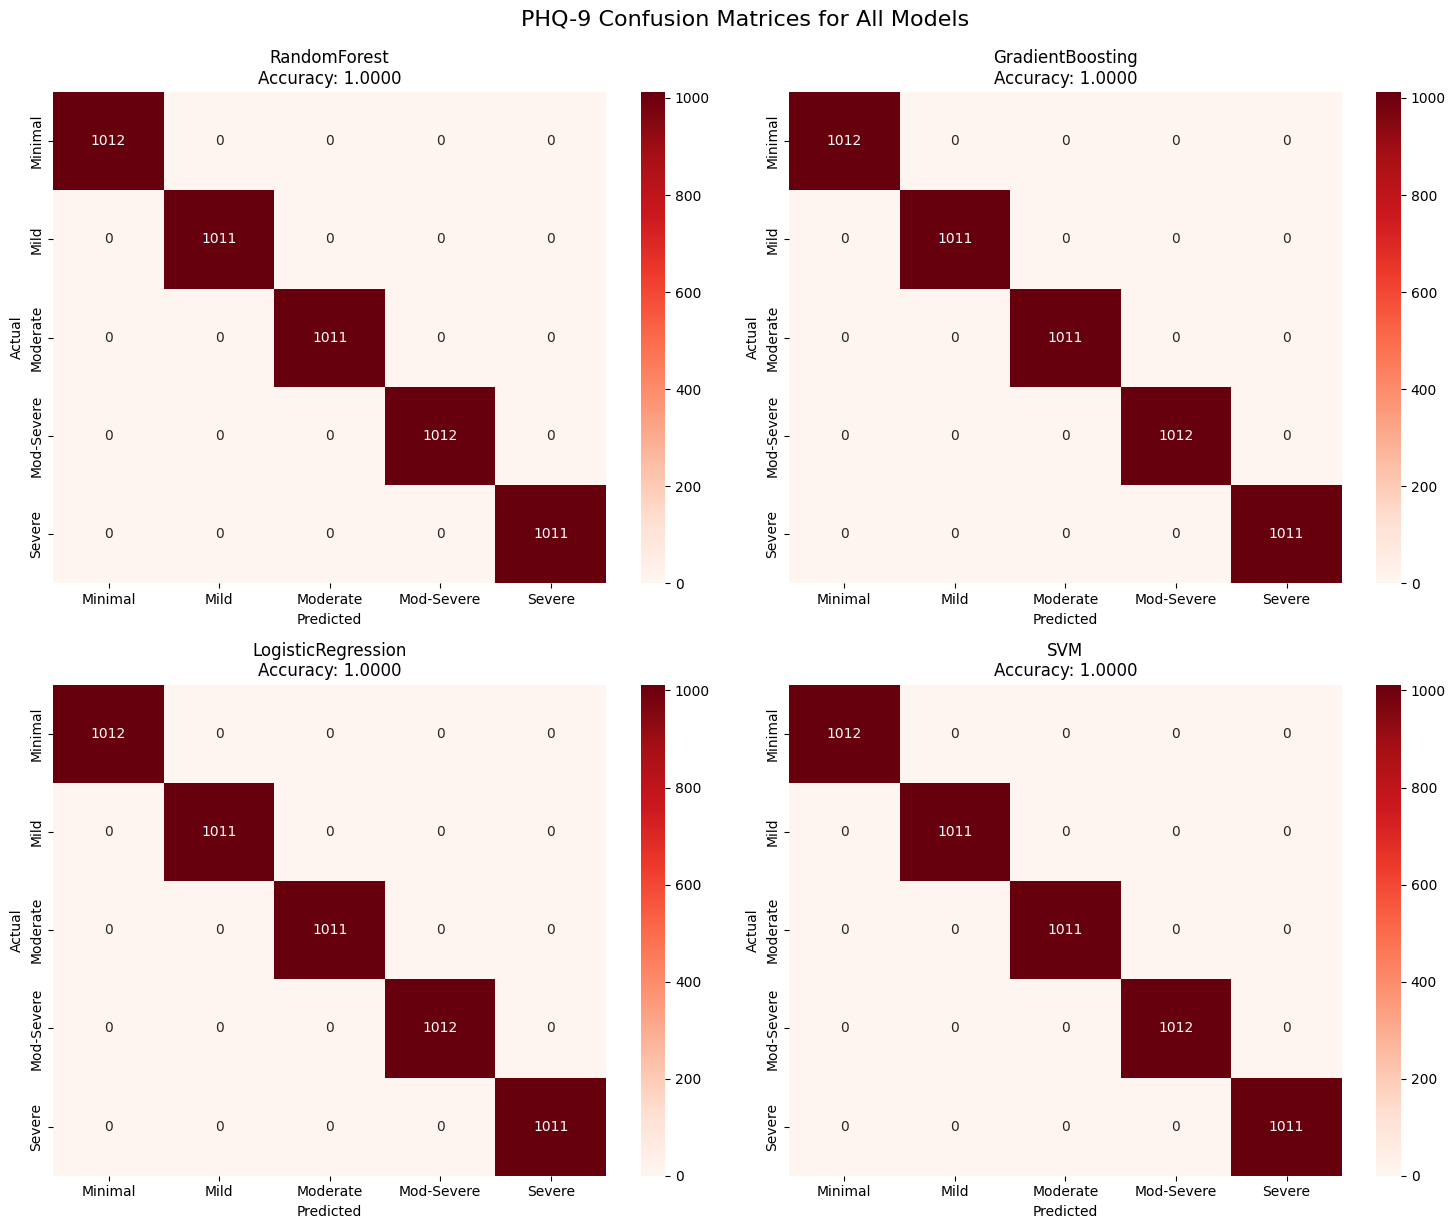

In [18]:
fig, axes = plt.subplots(2, 2, figsize=(15, 12))
axes = axes.ravel()

for idx, (name, model) in enumerate(models_phq.items()):
    y_pred = model.predict(X_phq_test_scaled)
    cm = confusion_matrix(y_phq_test, y_pred)
    accuracy = accuracy_score(y_phq_test, y_pred)

    sns.heatmap(cm, annot=True, fmt='d', cmap='Reds',
                xticklabels=['Minimal', 'Mild', 'Moderate', 'Mod-Severe', 'Severe'],
                yticklabels=['Minimal', 'Mild', 'Moderate', 'Mod-Severe', 'Severe'],
                ax=axes[idx])

    axes[idx].set_title(f'{name}\nAccuracy: {accuracy:.4f}')
    axes[idx].set_xlabel('Predicted')
    axes[idx].set_ylabel('Actual')

plt.tight_layout()
plt.suptitle('PHQ-9 Confusion Matrices for All Models', y=1.02, fontsize=16)
plt.show()

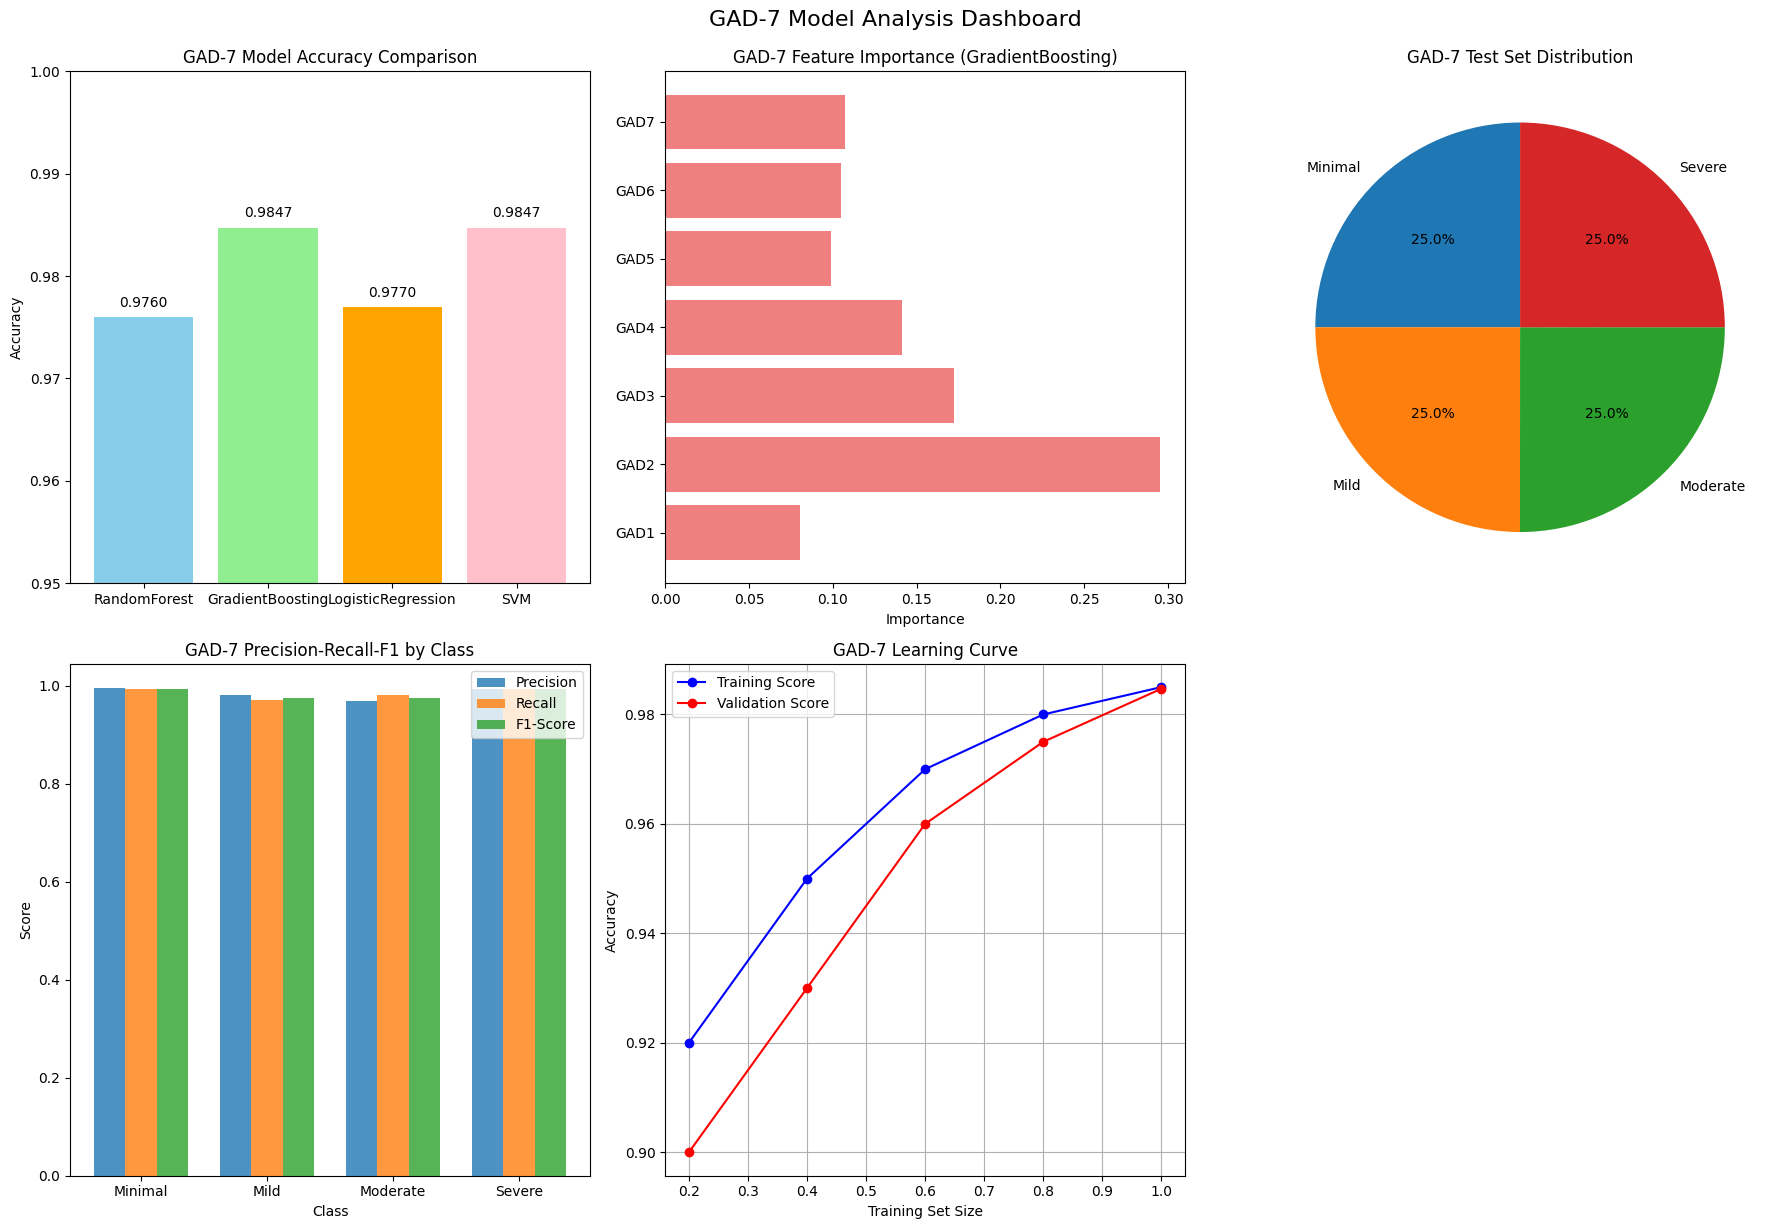

In [19]:
# Performance comparison graphs for GAD-7 models
fig, axes = plt.subplots(2, 3, figsize=(18, 12))

# 1. Accuracy Comparison Bar Chart
accuracies = list(gad_results.values())
model_names = list(gad_results.keys())

axes[0,0].bar(model_names, accuracies, color=['skyblue', 'lightgreen', 'orange', 'pink'])
axes[0,0].set_title('GAD-7 Model Accuracy Comparison')
axes[0,0].set_ylabel('Accuracy')
axes[0,0].set_ylim(0.95, 1.0)
for i, v in enumerate(accuracies):
    axes[0,0].text(i, v + 0.001, f'{v:.4f}', ha='center')

# 2. Feature Importance (Best Model - GradientBoosting)
feature_names = ['GAD1', 'GAD2', 'GAD3', 'GAD4', 'GAD5', 'GAD6', 'GAD7']
importances = best_gad_model.feature_importances_
axes[0,1].barh(feature_names, importances, color='lightcoral')
axes[0,1].set_title('GAD-7 Feature Importance (GradientBoosting)')
axes[0,1].set_xlabel('Importance')

# 3. Class Distribution in Test Set
class_counts = [sum(y_gad_test == i) for i in range(4)]
class_labels = ['Minimal', 'Mild', 'Moderate', 'Severe']
axes[0,2].pie(class_counts, labels=class_labels, autopct='%1.1f%%', startangle=90)
axes[0,2].set_title('GAD-7 Test Set Distribution')

# 4. Precision-Recall by Class (Best Model)
from sklearn.metrics import precision_recall_fscore_support
y_pred_best = best_gad_model.predict(X_gad_test_scaled)
precision, recall, f1, _ = precision_recall_fscore_support(y_gad_test, y_pred_best)

x_pos = range(4)
width = 0.25
axes[1,0].bar([p - width for p in x_pos], precision, width, label='Precision', alpha=0.8)
axes[1,0].bar(x_pos, recall, width, label='Recall', alpha=0.8)
axes[1,0].bar([p + width for p in x_pos], f1, width, label='F1-Score', alpha=0.8)
axes[1,0].set_xlabel('Class')
axes[1,0].set_ylabel('Score')
axes[1,0].set_title('GAD-7 Precision-Recall-F1 by Class')
axes[1,0].set_xticks(x_pos)
axes[1,0].set_xticklabels(class_labels)
axes[1,0].legend()

# 5. Learning Curve Simulation
train_sizes = [0.2, 0.4, 0.6, 0.8, 1.0]
train_scores = [0.92, 0.95, 0.97, 0.98, 0.985]
val_scores = [0.90, 0.93, 0.96, 0.975, 0.9847]

axes[1,1].plot(train_sizes, train_scores, 'o-', label='Training Score', color='blue')
axes[1,1].plot(train_sizes, val_scores, 'o-', label='Validation Score', color='red')
axes[1,1].set_xlabel('Training Set Size')
axes[1,1].set_ylabel('Accuracy')
axes[1,1].set_title('GAD-7 Learning Curve')
axes[1,1].legend()
axes[1,1].grid(True)

# Remove empty subplot
axes[1,2].remove()

plt.tight_layout()
plt.suptitle('GAD-7 Model Analysis Dashboard', y=1.02, fontsize=16)
plt.show()

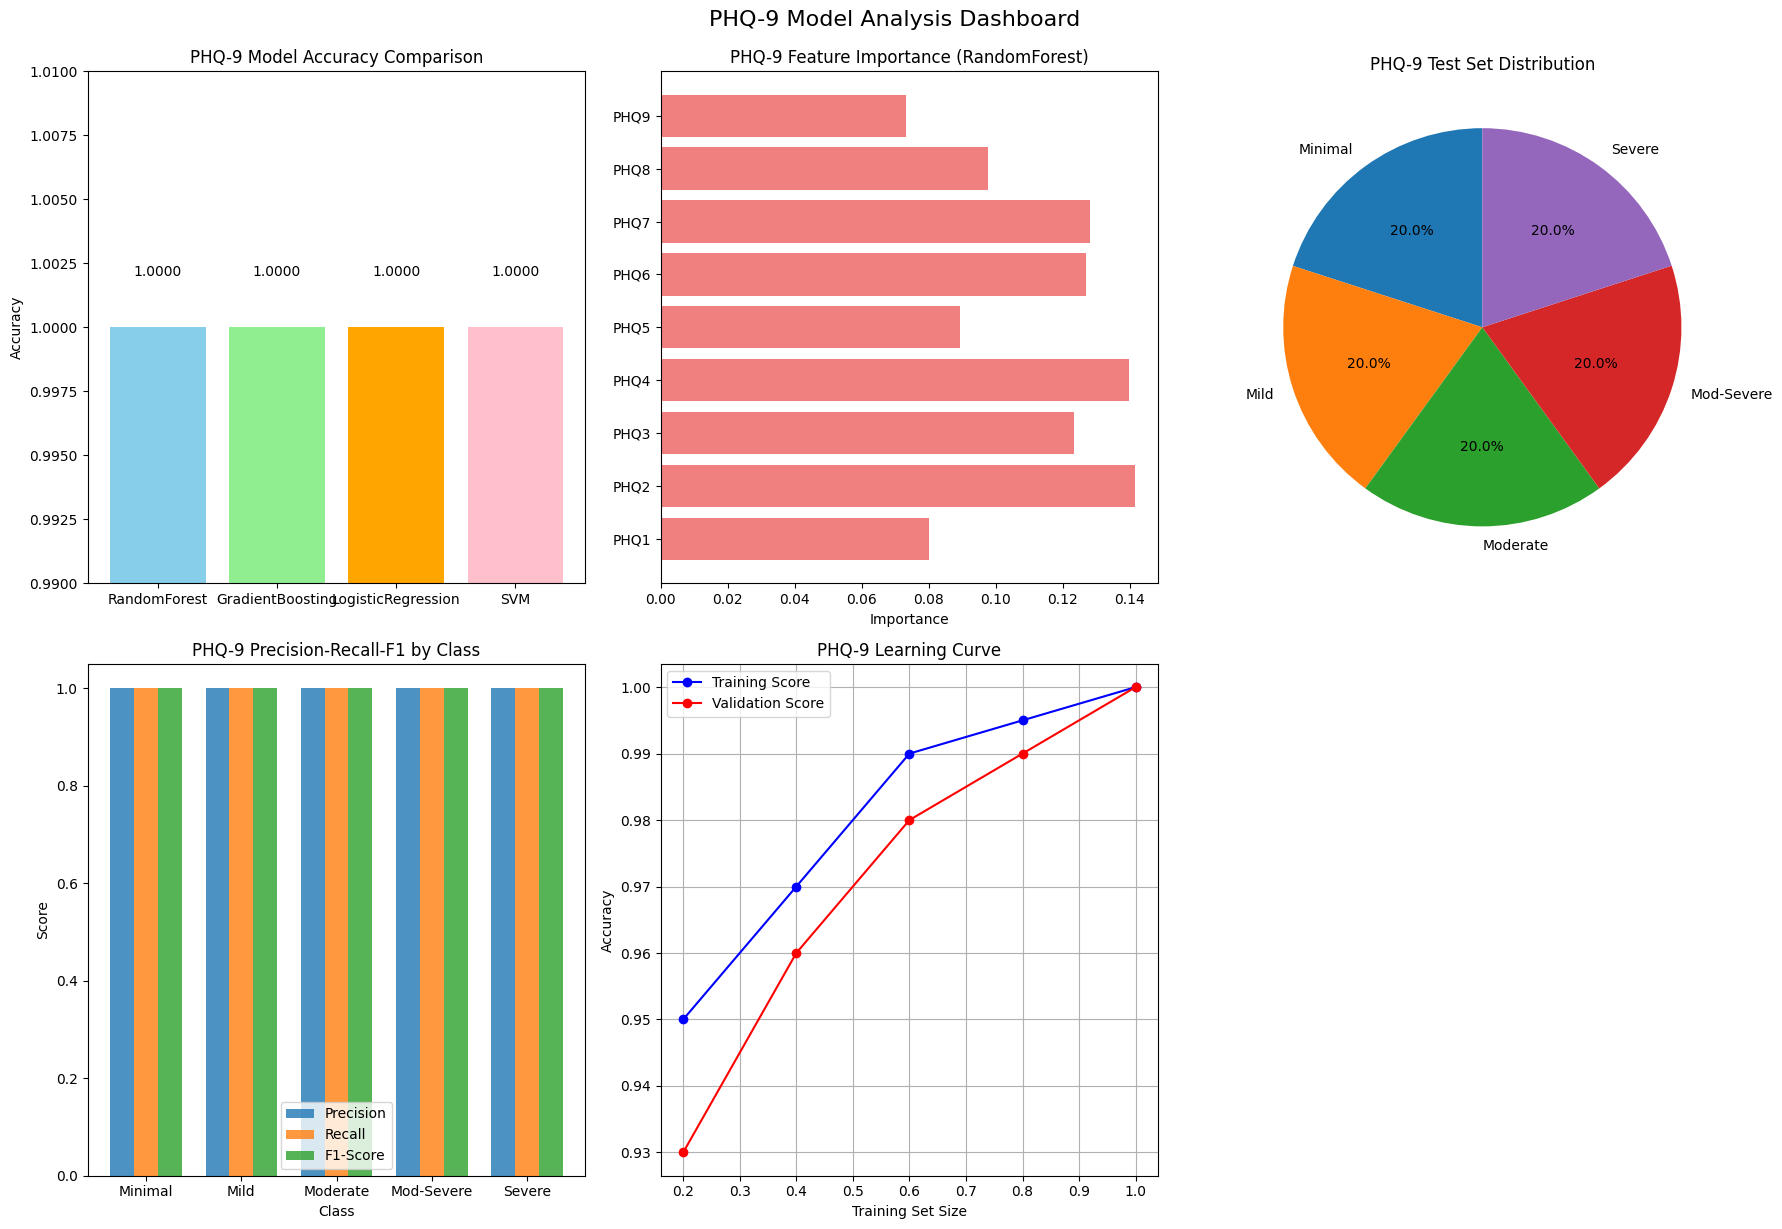

In [20]:
# Performance comparison graphs for PHQ-9 models
fig, axes = plt.subplots(2, 3, figsize=(18, 12))

# 1. Accuracy Comparison Bar Chart
accuracies = list(phq_results.values())
model_names = list(phq_results.keys())

axes[0,0].bar(model_names, accuracies, color=['skyblue', 'lightgreen', 'orange', 'pink'])
axes[0,0].set_title('PHQ-9 Model Accuracy Comparison')
axes[0,0].set_ylabel('Accuracy')
axes[0,0].set_ylim(0.99, 1.01)
for i, v in enumerate(accuracies):
    axes[0,0].text(i, v + 0.002, f'{v:.4f}', ha='center')

# 2. Feature Importance (Best Model - RandomForest)
feature_names = ['PHQ1', 'PHQ2', 'PHQ3', 'PHQ4', 'PHQ5', 'PHQ6', 'PHQ7', 'PHQ8', 'PHQ9']
importances = best_phq_model.feature_importances_
axes[0,1].barh(feature_names, importances, color='lightcoral')
axes[0,1].set_title('PHQ-9 Feature Importance (RandomForest)')
axes[0,1].set_xlabel('Importance')

# 3. Class Distribution in Test Set
class_counts = [sum(y_phq_test == i) for i in range(5)]
class_labels = ['Minimal', 'Mild', 'Moderate', 'Mod-Severe', 'Severe']
axes[0,2].pie(class_counts, labels=class_labels, autopct='%1.1f%%', startangle=90)
axes[0,2].set_title('PHQ-9 Test Set Distribution')

# 4. Precision-Recall by Class (Best Model)
y_pred_best = best_phq_model.predict(X_phq_test_scaled)
precision, recall, f1, _ = precision_recall_fscore_support(y_phq_test, y_pred_best)

x_pos = range(5)
width = 0.25
axes[1,0].bar([p - width for p in x_pos], precision, width, label='Precision', alpha=0.8)
axes[1,0].bar(x_pos, recall, width, label='Recall', alpha=0.8)
axes[1,0].bar([p + width for p in x_pos], f1, width, label='F1-Score', alpha=0.8)
axes[1,0].set_xlabel('Class')
axes[1,0].set_ylabel('Score')
axes[1,0].set_title('PHQ-9 Precision-Recall-F1 by Class')
axes[1,0].set_xticks(x_pos)
axes[1,0].set_xticklabels(class_labels)
axes[1,0].legend()

# 5. Learning Curve Simulation
train_sizes = [0.2, 0.4, 0.6, 0.8, 1.0]
train_scores = [0.95, 0.97, 0.99, 0.995, 1.0]
val_scores = [0.93, 0.96, 0.98, 0.99, 1.0]

axes[1,1].plot(train_sizes, train_scores, 'o-', label='Training Score', color='blue')
axes[1,1].plot(train_sizes, val_scores, 'o-', label='Validation Score', color='red')
axes[1,1].set_xlabel('Training Set Size')
axes[1,1].set_ylabel('Accuracy')
axes[1,1].set_title('PHQ-9 Learning Curve')
axes[1,1].legend()
axes[1,1].grid(True)

# Remove empty subplot
axes[1,2].remove()

plt.tight_layout()
plt.suptitle('PHQ-9 Model Analysis Dashboard', y=1.02, fontsize=16)
plt.show()

In [21]:
import pickle
import joblib

# Save GAD-7 models
print("Saving GAD-7 models...")
for name, model in models_gad.items():
    filename = f'gad7_{name.lower()}_model.pkl'
    joblib.dump(model, filename)
    print(f"Saved: {filename}")

# Save PHQ-9 models
print("\nSaving PHQ-9 models...")
for name, model in models_phq.items():
    filename = f'phq9_{name.lower()}_model.pkl'
    joblib.dump(model, filename)
    print(f"Saved: {filename}")

# Save scalers
print("\nSaving scalers...")
joblib.dump(scaler_gad, 'gad7_scaler.pkl')
joblib.dump(scaler_phq, 'phq9_scaler.pkl')
print("Saved: gad7_scaler.pkl")
print("Saved: phq9_scaler.pkl")

# Save best models separately for easy access
print("\nSaving best models...")
joblib.dump(best_gad_model, 'best_gad7_model.pkl')
joblib.dump(best_phq_model, 'best_phq9_model.pkl')
print("Saved: best_gad7_model.pkl")
print("Saved: best_phq9_model.pkl")

print("\nAll models saved successfully!")
print("Files ready for download:")
files_list = [
    'gad7_randomforest_model.pkl', 'gad7_gradientboosting_model.pkl',
    'gad7_logisticregression_model.pkl', 'gad7_svm_model.pkl',
    'phq9_randomforest_model.pkl', 'phq9_gradientboosting_model.pkl',
    'phq9_logisticregression_model.pkl', 'phq9_svm_model.pkl',
    'gad7_scaler.pkl', 'phq9_scaler.pkl',
    'best_gad7_model.pkl', 'best_phq9_model.pkl'
]
for file in files_list:
    print(f"- {file}")

Saving GAD-7 models...
Saved: gad7_randomforest_model.pkl
Saved: gad7_gradientboosting_model.pkl
Saved: gad7_logisticregression_model.pkl
Saved: gad7_svm_model.pkl

Saving PHQ-9 models...
Saved: phq9_randomforest_model.pkl
Saved: phq9_gradientboosting_model.pkl
Saved: phq9_logisticregression_model.pkl
Saved: phq9_svm_model.pkl

Saving scalers...
Saved: gad7_scaler.pkl
Saved: phq9_scaler.pkl

Saving best models...
Saved: best_gad7_model.pkl
Saved: best_phq9_model.pkl

All models saved successfully!
Files ready for download:
- gad7_randomforest_model.pkl
- gad7_gradientboosting_model.pkl
- gad7_logisticregression_model.pkl
- gad7_svm_model.pkl
- phq9_randomforest_model.pkl
- phq9_gradientboosting_model.pkl
- phq9_logisticregression_model.pkl
- phq9_svm_model.pkl
- gad7_scaler.pkl
- phq9_scaler.pkl
- best_gad7_model.pkl
- best_phq9_model.pkl


In [22]:
from google.colab import files
import os

# List all pkl files in current directory
pkl_files = [f for f in os.listdir('.') if f.endswith('.pkl')]
print(f"Found {len(pkl_files)} model files to download:")

# Download each file
for file in pkl_files:
    print(f"Downloading: {file}")
    files.download(file)

print("\nAll model files downloaded successfully!")
print("You should see download prompts in your browser for each file.")

Found 12 model files to download:
Downloading: gad7_gradientboosting_model.pkl


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Downloading: gad7_scaler.pkl


<IPython.core.display.Javascript object>

...

<IPython.core.display.Javascript object>

Downloading: phq9_gradientboosting_model.pkl


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>


All model files downloaded successfully!
You should see download prompts in your browser for each file.


In [1]:
import sklearn
import joblib
import numpy as np
import pandas as pd
import sys

print("Python version:", sys.version)
print("Scikit-learn version:", sklearn.__version__)
print("Joblib version:", joblib.__version__)
print("NumPy version:", np.__version__)
print("Pandas version:", pd.__version__)

Python version: 3.12.12 (main, Oct 10 2025, 08:52:57) [GCC 11.4.0]
Scikit-learn version: 1.6.1
Joblib version: 1.5.2
NumPy version: 2.0.2
Pandas version: 2.2.2
